# LLM06: Attention Mechanisms - The Heart of Transformers

## Lab Overview

| Section | Topic                         | Key Concepts                                                     |
| ------- | ----------------------------- | ---------------------------------------------------------------- |
| 2       | Self-Attention Fundamentals   | Q/K/V projections, `nn.Linear`, Xavier init                      |
| 3       | Attention Scores & Masking    | Scaled dot-product, causal mask (`torch.triu`), padding mask     |
| 4       | Multi-Head Attention          | Head splitting, parallel computation, concat + output projection |
| 5       | Grouped Query Attention (GQA) | KV sharing across head groups, MHA → GQA → MQA spectrum          |

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (e.g., AI Max+ 395, AI Max 390)

#### Software Environment

OS: Ubuntu 24.04.3 LTS \
Install [AUP Learning Cloud](https://amdresearch.github.io/aup-learning-cloud/installation/quick-start.html?family=ryzen-ai&gpu=…). After installing AUP Learning Cloud, you will have a ROCm and PyTorch environment that is compatible with this notebook.

## Goals

1. **Understand Self-Attention**: Grasp the mathematical intuition behind $\text{softmax}(QK^T/\sqrt{d_k})V$.
2. **Implement Attention Components**: Build Q, K, V projections from scratch.
3. **Master Multi-Head Attention**: Understand parallel attention heads and their benefits.
4. **Apply Causal Masking**: Implement autoregressive attention for language modeling.
5. **Implement GQA**: Build Grouped Query Attention and compare with standard MHA.
6. **Connect to Real Models**: Map attention variants to LLaMA, Mistral, GPT architectures.

---


## 1. Environment Setup


In [25]:
# Core libraries for attention implementation
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
PyTorch version: 2.9.1+rocm7.2.0.git7e1940d4
GPU: AMD Radeon(TM) 8060S Graphics
GPU Memory: 102.7 GB


## 2. Self-Attention Fundamentals

Self-attention allows each position in a sequence to attend to all positions in the same sequence. This mechanism enables the model to capture complex relationships and dependencies within the input.

**Core Components:**

**Query (Q)**: Represents "what am I looking for?"

- Each position creates a query vector asking what information it needs
- Computed by: `Q = X * W_q`

**Key (K)**: Represents "what do I have to offer?"

- Each position creates a key vector describing what information it contains
- Computed by: `K = X * W_k`

**Value (V)**: Represents "what information do I actually contain?"

- Each position creates a value vector with the actual information to be shared
- Computed by: `V = X * W_v`

**Attention Mechanism Steps:**

1. **Compute Scores**: Calculate similarity between queries and keys: `QK^T`
2. **Scale**: Divide by `√d_k` for numerical stability
3. **Apply Softmax**: Convert scores to probabilities
4. **Weighted Sum**: Multiply probabilities with values: `softmax(QK^T/√d_k)V`

**Mathematical Intuition:**
The attention score between position i and j represents how much position i should focus on position j. Higher scores mean stronger relationships and more information flow.


In [26]:
# Initialize Attention Components and Test Data
print("Setting up attention mechanism components")

# Model parameters
batch_size = 2
seq_len = 3
hidden_dim = 4
head_dim = 2  # For multi-head attention later

# Create sample input embeddings
hidden_states = torch.randn(batch_size, seq_len, hidden_dim).to(device)
print(f"Input shape: {hidden_states.shape}")
print(f"Input tensor:\n{hidden_states}")

# Initialize projection layers for Q, K, V
q_proj = nn.Linear(hidden_dim, hidden_dim, bias=False).to(device)
k_proj = nn.Linear(hidden_dim, hidden_dim, bias=False).to(device)
v_proj = nn.Linear(hidden_dim, hidden_dim, bias=False).to(device)
o_proj = nn.Linear(hidden_dim, hidden_dim, bias=False).to(device)  # Output projection

print("\nProjection layers initialized:")
print(f"- Query projection: {hidden_dim} -> {hidden_dim}")
print(f"- Key projection: {hidden_dim} -> {hidden_dim}")
print(f"- Value projection: {hidden_dim} -> {hidden_dim}")
print(f"- Output projection: {hidden_dim} -> {hidden_dim}")

# Initialize weights with small values for stability
with torch.no_grad():
    for proj in [q_proj, k_proj, v_proj, o_proj]:
        nn.init.xavier_uniform_(proj.weight)

print("Projection weights initialized with Xavier uniform distribution")

Setting up attention mechanism components
Input shape: torch.Size([2, 3, 4])
Input tensor:
tensor([[[ 1.9269,  1.4873,  0.9007, -2.1055],
         [ 0.6784, -1.2345, -0.0431, -1.6047],
         [ 0.3559, -0.6866, -0.4934,  0.2415]],

        [[-1.1109,  0.0915, -2.3169, -0.2168],
         [-0.3097, -0.3957,  0.8034, -0.6216],
         [-0.5920, -0.0631, -0.8286,  0.3309]]], device='cuda:0')

Projection layers initialized:
- Query projection: 4 -> 4
- Key projection: 4 -> 4
- Value projection: 4 -> 4
- Output projection: 4 -> 4
Projection weights initialized with Xavier uniform distribution


In [27]:
# Compute Query, Key, and Value Projections
print("Computing Q, K, V projections from input embeddings")

# Apply linear transformations to create Q, K, V
q = q_proj(hidden_states)  # Query: "what am I looking for?"
k = k_proj(hidden_states)  # Key: "what do I have to offer?"
v = v_proj(hidden_states)  # Value: "what information do I contain?"

print("\nProjection results:")
print(f"Query (Q) shape: {q.shape}")
print(f"Key (K) shape: {k.shape}")
print(f"Value (V) shape: {v.shape}")

# Analyze the projections
print("\nQuery statistics:")
print(f"- Mean: {q.mean().item():.4f}")
print(f"- Std: {q.std().item():.4f}")
print(f"- Range: [{q.min().item():.4f}, {q.max().item():.4f}]")

print("\nFirst query vector (batch 0, position 0):")
print(f"Q[0,0,:] = {q[0, 0, :]}")

print("\nFirst key vector (batch 0, position 0):")
print(f"K[0,0,:] = {k[0, 0, :]}")

print("\nFirst value vector (batch 0, position 0):")
print(f"V[0,0,:] = {v[0, 0, :]}")

# Demonstrate that each position has its own Q, K, V vectors
print("\nPosition-specific vectors for batch 0:")
for pos in range(seq_len):
    q_norm = q[0, pos, :].norm().item()
    k_norm = k[0, pos, :].norm().item()
    v_norm = v[0, pos, :].norm().item()
    print(f"Position {pos}: Q_norm={q_norm:.3f}, K_norm={k_norm:.3f}, V_norm={v_norm:.3f}")

Computing Q, K, V projections from input embeddings

Projection results:
Query (Q) shape: torch.Size([2, 3, 4])
Key (K) shape: torch.Size([2, 3, 4])
Value (V) shape: torch.Size([2, 3, 4])

Query statistics:
- Mean: 0.2677
- Std: 1.0137
- Range: [-2.4316, 2.5528]

First query vector (batch 0, position 0):
Q[0,0,:] = tensor([ 0.6328, -0.4809, -2.4316,  1.2492], device='cuda:0',
       grad_fn=<SelectBackward0>)

First key vector (batch 0, position 0):
K[0,0,:] = tensor([0.6881, 0.3357, 1.3903, 1.4260], device='cuda:0',
       grad_fn=<SelectBackward0>)

First value vector (batch 0, position 0):
V[0,0,:] = tensor([1.3583, 2.0770, 1.7692, 1.3241], device='cuda:0',
       grad_fn=<SelectBackward0>)

Position-specific vectors for batch 0:
Position 0: Q_norm=2.847, K_norm=2.134, V_norm=3.323
Position 1: Q_norm=3.615, K_norm=2.229, V_norm=2.604
Position 2: Q_norm=1.177, K_norm=0.738, V_norm=0.912


## 3. Attention Score Computation and Masking

Now we'll compute attention scores and explore masking techniques for different types of attention patterns.

**Attention Score Computation:**

1. **Dot Product**: Compute similarity between queries and keys: `QK^T`
2. **Scaling**: Divide by `√d_k` to prevent extremely large values
3. **Masking**: Apply masks to control which positions can attend to others
4. **Softmax**: Convert scores to probability distribution

**Types of Attention Masks:**

- **Causal Mask**: For autoregressive models (GPT-style), prevents looking at future tokens
- **Padding Mask**: Ignores padded positions in variable-length sequences
- **Custom Masks**: Application-specific attention patterns

**Mathematical Details:**

- Here `d_k` means the last dimension of each query/key vector.
- In this single-head toy example, `d_k = hidden_dim`; in multi-head attention, `d_k = head_dim`.
- **Scaling Factor**: `√d_k` prevents softmax from saturating for large dimensions
- **Causal Pattern**: Lower triangular matrix ensures position i only sees positions ≤ i
- **Mask Values**: Set to -∞ before softmax to get 0 probability after softmax


In [28]:
# Compute Attention Scores with Detailed Analysis
print("Computing attention scores: QK^T / sqrt(d_k)")

# Step 1: Compute raw attention scores
# q, k have last dimension d_k
d_k = q.size(-1)
scale_factor = math.sqrt(d_k)
attention_scores = torch.matmul(q, k.transpose(-2, -1)) / scale_factor

print(f"Attention scores shape: {attention_scores.shape}")
print(f"Scale factor (sqrt(d_k)): {scale_factor}")
print("Raw attention scores (batch 0):")
print(attention_scores[0])

# Analyze attention patterns
print("\nAttention score statistics:")
print(f"- Mean: {attention_scores.mean().item():.4f}")
print(f"- Std: {attention_scores.std().item():.4f}")
print(f"- Range: [{attention_scores.min().item():.4f}, {attention_scores.max().item():.4f}]")

# Step 2: Create and apply causal mask
print("\nCreating causal mask for autoregressive attention:")
causal_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
causal_mask = causal_mask.to(attention_scores.device)
print(f"Causal mask shape: {causal_mask.shape}")
print("Causal mask pattern:")
print(causal_mask.int())

# Apply mask by setting masked positions to very negative values
masked_scores = attention_scores.clone()
masked_scores = masked_scores.masked_fill(causal_mask, float("-inf"))

print("\nMasked attention scores (batch 0):")
print(masked_scores[0])

# Step 3: Demonstrate different masking strategies
print("\nDemonstrating padding mask:")
# Simulate padding mask (position 2 is padded)
padding_mask = torch.zeros(batch_size, seq_len).bool()
padding_mask[1, 2] = True  # Mark position 2 in batch 1 as padded

print("Padding mask:")
print(padding_mask)

# Apply padding mask
# This padding mask removes padded key/value positions from being attended to.
# In practice, padded query positions are also usually ignored later (for example in the loss).
padding_masked_scores = attention_scores.clone()
padding_masked_scores[padding_mask.unsqueeze(1).expand(-1, seq_len, -1)] = float("-inf")

print("Scores with padding mask (batch 1):")
print(padding_masked_scores[1])

Computing attention scores: QK^T / sqrt(d_k)
Attention scores shape: torch.Size([2, 3, 3])
Scale factor (sqrt(d_k)): 2.0
Raw attention scores (batch 0):
tensor([[-0.6626,  1.6580,  0.2725],
        [ 2.1767,  3.5629,  0.7366],
        [ 1.0602,  1.0616,  0.1678]], device='cuda:0',
       grad_fn=<SelectBackward0>)

Attention score statistics:
- Mean: 0.4682
- Std: 1.1305
- Range: [-1.3013, 3.5629]

Creating causal mask for autoregressive attention:
Causal mask shape: torch.Size([3, 3])
Causal mask pattern:
tensor([[0, 1, 1],
        [0, 0, 1],
        [0, 0, 0]], device='cuda:0', dtype=torch.int32)

Masked attention scores (batch 0):
tensor([[-0.6626,    -inf,    -inf],
        [ 2.1767,  3.5629,    -inf],
        [ 1.0602,  1.0616,  0.1678]], device='cuda:0',
       grad_fn=<SelectBackward0>)

Demonstrating padding mask:
Padding mask:
tensor([[False, False, False],
        [False, False,  True]])
Scores with padding mask (batch 1):
tensor([[-0.0569, -0.1291,    -inf],
        [-1.3013

In [29]:
# Apply Softmax and Compute Attention Output
print("Applying softmax to convert scores to attention weights")

# Step 1: Apply softmax to get attention probabilities
attention_weights = F.softmax(masked_scores, dim=-1)
print(f"Attention weights shape: {attention_weights.shape}")
print("Attention weights (batch 0):")
print(attention_weights[0])

# Verify softmax properties
print("\nSoftmax verification:")
for batch in range(batch_size):
    row_sums = attention_weights[batch].sum(dim=-1)
    print(f"Batch {batch} row sums: {row_sums} (should sum to 1.0)")

# Step 2: Apply attention weights to values
attention_output = torch.matmul(attention_weights, v)
print(f"\nAttention output shape: {attention_output.shape}")
print("Attention output (batch 0):")
print(attention_output[0])

# Step 3: Analyze what attention is doing
print("\nAttention interpretation:")
print("Position 0 attention weights:", attention_weights[0, 0, :])
print("Position 0 can only attend to itself (causal mask)")
print()
print("Position 1 attention weights:", attention_weights[0, 1, :])
print("Position 1 can attend to positions 0 and 1")
print()
print("Position 2 attention weights:", attention_weights[0, 2, :])
print("Position 2 can attend to all positions 0, 1, and 2")

# Step 4: Compare input vs output
print("\nInput vs Output comparison (batch 0, position 0):")
print(f"Original hidden state: {hidden_states[0, 0, :]}")
print(f"Attention output:     {attention_output[0, 0, :]}")
print(f"Change magnitude: {(attention_output[0, 0, :] - hidden_states[0, 0, :]).norm().item():.4f}")

# Step 5: Demonstrate attention focusing
print("\nAttention focusing analysis:")
max_attention = attention_weights.max(dim=-1)[0]
print("Maximum attention weights per position:")
print(f"Batch 0: {max_attention[0]}")
print(f"Batch 1: {max_attention[1]}")
print("Higher values indicate more focused attention")

Applying softmax to convert scores to attention weights
Attention weights shape: torch.Size([2, 3, 3])
Attention weights (batch 0):
tensor([[1.0000, 0.0000, 0.0000],
        [0.2000, 0.8000, 0.0000],
        [0.4147, 0.4153, 0.1699]], device='cuda:0', grad_fn=<SelectBackward0>)

Softmax verification:
Batch 0 row sums: tensor([1., 1., 1.], device='cuda:0', grad_fn=<SumBackward1>) (should sum to 1.0)
Batch 1 row sums: tensor([1.0000, 1.0000, 1.0000], device='cuda:0', grad_fn=<SumBackward1>) (should sum to 1.0)

Attention output shape: torch.Size([2, 3, 4])
Attention output (batch 0):
tensor([[ 1.3583,  2.0770,  1.7692,  1.3241],
        [ 1.4537,  1.9112, -0.0862,  0.9790],
        [ 1.2232,  1.6353,  0.3632,  0.9614]], device='cuda:0',
       grad_fn=<SelectBackward0>)

Attention interpretation:
Position 0 attention weights: tensor([1., 0., 0.], device='cuda:0', grad_fn=<SelectBackward0>)
Position 0 can only attend to itself (causal mask)

Position 1 attention weights: tensor([0.2000, 0

## 4. Multi-Head Attention

For teaching clarity, we first computed a single-head style attention over the full hidden dimension. Real implementations usually project directly into multiple heads and process them in parallel.

Multi-head attention allows the model to attend to information from different representation subspaces simultaneously. Instead of performing a single attention function, we run multiple attention heads in parallel.

**Key Concepts:**

**Multiple Attention Heads:**

- Each head focuses on different types of relationships
- Heads operate on different subspaces of the input
- Parallel computation enables efficiency

**Head Dimension Calculation:**

- `head_dim = hidden_dim / num_heads`
- Each head gets a portion of the full dimension
- Maintains total parameter count(Splitting into heads keeps the overall projection dimensions the same (when using standard fused Q/K/V projections), while allowing different heads to learn different patterns.)

**Parallel Processing:**

- Reshape tensors to process all heads simultaneously
- More efficient than sequential head computation
- Enables better GPU utilization

**Mathematical Formulation:**

```
MultiHead(Q,K,V) = Concat(head_1, ..., head_h)W^O
where head_i = Attention(QW_i^Q, KW_i^K, VW_i^V)
```

**Implementation Strategy:**

1. Reshape Q, K, V into multiple heads
2. Apply attention computation to all heads in parallel
3. Concatenate head outputs
4. Apply final linear projection


In [30]:
# Implement Multi-Head Attention
print("Implementing multi-head attention mechanism")

# Configuration for multi-head attention
num_heads = 2
head_dim = hidden_dim // num_heads
print(f"Number of heads: {num_heads}")
print(f"Head dimension: {head_dim}")
print(f"Total dimension: {num_heads * head_dim}")

# Step 1: Reshape Q, K, V for multi-head processing
print("\nReshaping for multi-head attention:")
print(f"Original shape: {q.shape}")

# Reshape: [batch, seq_len, hidden_dim] -> [batch, seq_len, num_heads, head_dim]
q_heads = q.view(batch_size, seq_len, num_heads, head_dim)
k_heads = k.view(batch_size, seq_len, num_heads, head_dim)
v_heads = v.view(batch_size, seq_len, num_heads, head_dim)

# Transpose: [batch, seq_len, num_heads, head_dim] -> [batch, num_heads, seq_len, head_dim]
q_heads = q_heads.transpose(1, 2)
k_heads = k_heads.transpose(1, 2)
v_heads = v_heads.transpose(1, 2)

print(f"Multi-head shape: {q_heads.shape}")
print(f"Shape interpretation: [batch={batch_size}, heads={num_heads}, seq_len={seq_len}, head_dim={head_dim}]")

# Step 2: Verify head separation
print("\nHead separation verification:")
print(f"Head 0 query (batch 0, position 0): {q_heads[0, 0, 0, :]}")
print(f"Head 1 query (batch 0, position 0): {q_heads[0, 1, 0, :]}")

# Step 3: Analyze head independence
head0_norm = q_heads[0, 0, :, :].norm(dim=-1)
head1_norm = q_heads[0, 1, :, :].norm(dim=-1)
print(f"\nHead 0 query norms: {head0_norm}")
print(f"Head 1 query norms: {head1_norm}")

# Step 4: Demonstrate that each head can learn different patterns
correlation = F.cosine_similarity(q_heads[0, 0, 0, :].unsqueeze(0), q_heads[0, 1, 0, :].unsqueeze(0))
print(f"Cosine similarity between head 0 and head 1 queries: {correlation.item():.4f}")
print(
    "Different vectors across heads illustrate that each head has its own subspace and can learn different patterns after training."
)

Implementing multi-head attention mechanism
Number of heads: 2
Head dimension: 2
Total dimension: 4

Reshaping for multi-head attention:
Original shape: torch.Size([2, 3, 4])
Multi-head shape: torch.Size([2, 2, 3, 2])
Shape interpretation: [batch=2, heads=2, seq_len=3, head_dim=2]

Head separation verification:
Head 0 query (batch 0, position 0): tensor([ 0.6328, -0.4809], device='cuda:0', grad_fn=<SelectBackward0>)
Head 1 query (batch 0, position 0): tensor([-2.4316,  1.2492], device='cuda:0', grad_fn=<SelectBackward0>)

Head 0 query norms: tensor([0.7948, 2.4687, 0.6970], device='cuda:0',
       grad_fn=<LinalgVectorNormBackward0>)
Head 1 query norms: tensor([2.7337, 2.6412, 0.9486], device='cuda:0',
       grad_fn=<LinalgVectorNormBackward0>)
Cosine similarity between head 0 and head 1 queries: -0.9847
Different vectors across heads illustrate that each head has its own subspace and can learn different patterns after training.


In [31]:
# Compute Multi-Head Attention
print("Computing attention for all heads simultaneously")

# Step 1: Compute attention scores for all heads
head_scale_factor = math.sqrt(head_dim)
multi_head_scores = torch.matmul(q_heads, k_heads.transpose(-2, -1)) / head_scale_factor

print(f"Multi-head attention scores shape: {multi_head_scores.shape}")
print(f"Head scale factor (sqrt(head_dim)): {head_scale_factor}")

# Step 2: Apply causal mask to all heads
causal_mask_expanded = causal_mask.unsqueeze(0).unsqueeze(0)  # [1, 1, seq_len, seq_len]
causal_mask_expanded = causal_mask_expanded.expand(batch_size, num_heads, -1, -1)

masked_multi_head_scores = multi_head_scores.masked_fill(causal_mask_expanded, float("-inf"))

print("\nMasked scores for head 0 (batch 0):")
print(masked_multi_head_scores[0, 0])
print("\nMasked scores for head 1 (batch 0):")
print(masked_multi_head_scores[0, 1])

# Step 3: Apply softmax to get attention weights
multi_head_weights = F.softmax(masked_multi_head_scores, dim=-1)

print(f"\nMulti-head attention weights shape: {multi_head_weights.shape}")

# Step 4: Compare attention patterns between heads
print("\nAttention Mechanism Summary:")
print("=" * 50)

# Calculate total parameters
total_params = sum(param.numel() for proj in [q_proj, k_proj, v_proj, o_proj] for param in proj.parameters())
print(f"Total parameters: {total_params:,}")

# Step 5: Analyze head diversity
head_diff = (multi_head_weights[0, 0] - multi_head_weights[0, 1]).abs().mean().item()
print(f"\nAverage absolute difference between heads: {head_diff:.4f}")
print("Higher values indicate more diverse attention patterns")

# Step 6: Apply attention weights to values
multi_head_output = torch.matmul(multi_head_weights, v_heads)
print(f"\nMulti-head output shape: {multi_head_output.shape}")

# Step 7: Concatenate heads
# Transpose back: [batch, num_heads, seq_len, head_dim] -> [batch, seq_len, num_heads, head_dim]
multi_head_output = multi_head_output.transpose(1, 2)

# Reshape: [batch, seq_len, num_heads, head_dim] -> [batch, seq_len, hidden_dim]
multi_head_output = multi_head_output.contiguous().view(batch_size, seq_len, hidden_dim)

print(f"Concatenated output shape: {multi_head_output.shape}")
print(f"Successfully restored original hidden dimension: {hidden_dim}")

Computing attention for all heads simultaneously
Multi-head attention scores shape: torch.Size([2, 2, 3, 3])
Head scale factor (sqrt(head_dim)): 1.4142135623730951

Masked scores for head 0 (batch 0):
tensor([[0.1937,   -inf,   -inf],
        [1.1705, 2.3592,   -inf],
        [0.1634, 0.8261, 0.3291]], device='cuda:0', grad_fn=<SelectBackward0>)

Masked scores for head 1 (batch 0):
tensor([[-1.1308,    -inf,    -inf],
        [ 1.9078,  2.6795,    -inf],
        [ 1.3359,  0.6752, -0.0918]], device='cuda:0',
       grad_fn=<SelectBackward0>)

Multi-head attention weights shape: torch.Size([2, 2, 3, 3])

Attention Mechanism Summary:
Total parameters: 64

Average absolute difference between heads: 0.0909
Higher values indicate more diverse attention patterns

Multi-head output shape: torch.Size([2, 2, 3, 2])
Concatenated output shape: torch.Size([2, 3, 4])
Successfully restored original hidden dimension: 4


Visualizing attention patterns


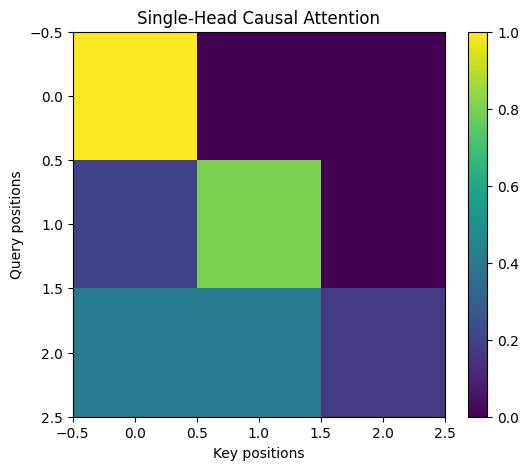

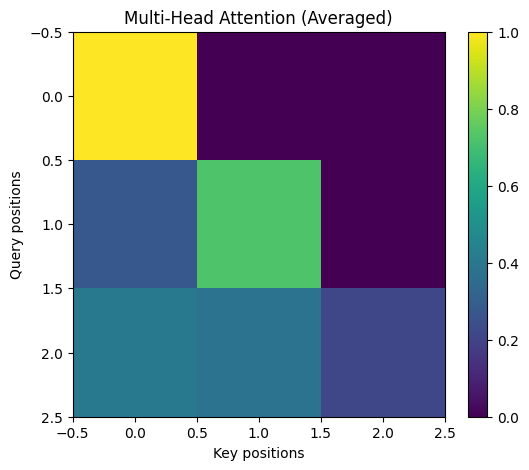

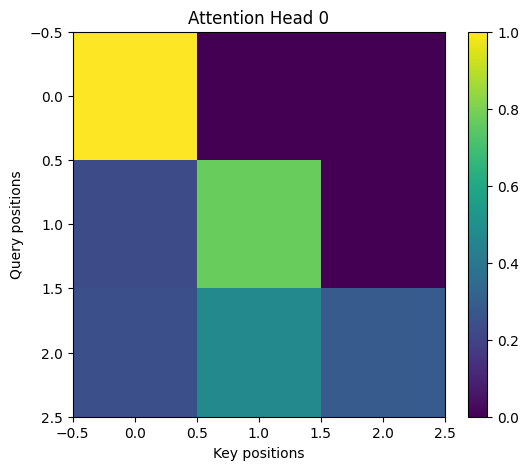

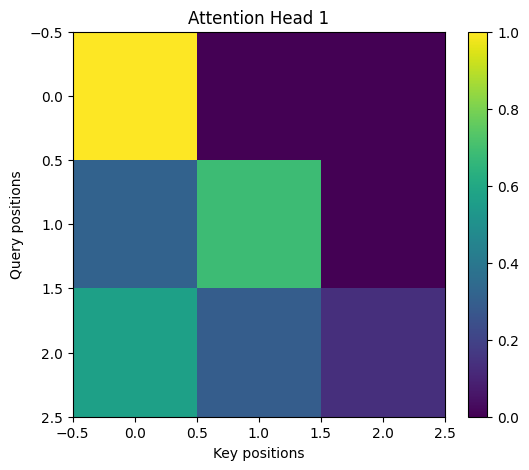


Visualization complete!


In [32]:
# Visualize Attention Patterns
print("Visualizing attention patterns")

import matplotlib.pyplot as plt


def show_attn(weights, title=""):
    """Visualize attention weights as a heatmap."""
    # Average through heads if 3D
    w = weights.mean(0) if weights.ndim == 3 else weights

    plt.figure(figsize=(6, 5))
    plt.imshow(w.detach().float().cpu().numpy(), aspect="auto", cmap="viridis")
    plt.xlabel("Key positions")
    plt.ylabel("Query positions")
    plt.title(title)
    plt.colorbar()
    plt.show()


# Visualize single-head attention
show_attn(attention_weights[0], title="Single-Head Causal Attention")

# Visualize multi-head attention (averaged)
show_attn(multi_head_weights[0], title="Multi-Head Attention (Averaged)")

# Visualize individual heads
for head_idx in range(num_heads):
    show_attn(multi_head_weights[0, head_idx], title=f"Attention Head {head_idx}")

print("\nVisualization complete!")

In [33]:
# Final Output Projection and Analysis
print("Applying final output projection and comprehensive analysis")

# Step 1: Apply output projection
final_output = o_proj(multi_head_output)
print(f"Final output shape: {final_output.shape}")
print("Final output (batch 0):")
print(final_output[0])

# Step 2: Compare single-head vs multi-head attention
print("\nSingle-head vs Multi-head Comparison:")
print(f"Single-head output norm: {attention_output.norm(dim=-1).mean().item():.4f}")
print(f"Multi-head output norm:  {final_output.norm(dim=-1).mean().item():.4f}")

# Step 3: Analyze the transformation
input_to_output_change = (final_output - hidden_states).norm(dim=-1).mean().item()
print("\nTransformation analysis:")
print(f"Average change from input to output: {input_to_output_change:.4f}")

# Step 4: Attention mechanism summary
print("\nAttention Mechanism Summary:")
print("=" * 50)

# Calculate total parameters
total_params = sum(param.numel() for proj in [q_proj, k_proj, v_proj, o_proj] for param in proj.parameters())
print(f"Total parameters: {total_params:,}")

# Computational complexity
seq_len_squared = seq_len * seq_len
print(f"Attention complexity: O(n²d) where n={seq_len}, d={hidden_dim}")
print(f"Attention operations per batch: {seq_len_squared * hidden_dim:,}")

# Memory usage
attention_memory = batch_size * num_heads * seq_len * seq_len * 4  # 4 bytes per float32
print(f"Attention weights memory: {attention_memory:,} bytes")

# Step 5: Demonstrate scalability insights

Applying final output projection and comprehensive analysis
Final output shape: torch.Size([2, 3, 4])
Final output (batch 0):
tensor([[-2.8048,  0.8286, -0.7160,  0.1611],
        [-1.2967, -0.0659, -1.5599,  0.2840],
        [-1.5152,  0.2548, -0.8387,  0.2782]], device='cuda:0',
       grad_fn=<SelectBackward0>)

Single-head vs Multi-head Comparison:
Single-head output norm: 2.3157
Multi-head output norm:  1.9745

Transformation analysis:
Average change from input to output: 3.3460

Attention Mechanism Summary:
Total parameters: 64
Attention complexity: O(n²d) where n=3, d=4
Attention operations per batch: 36
Attention weights memory: 144 bytes


### Scalability Insights

- Each doubling of sequence length increases attention cost by 4×
- Multi-head attention adds minimal computational overhead
- Most computation is in Q, K, V projections and attention weights
- GPU parallelization makes multi-head attention efficient


In [34]:
# Step 6: Show attention interpretability
print("\nAttention Interpretability:")
max_attention_pos = multi_head_weights[0, 0, -1, :].argmax().item()
max_attention_val = multi_head_weights[0, 0, -1, max_attention_pos].item()
print(f"Last position (pos {seq_len - 1}) attends most to position {max_attention_pos}")
print(f"Maximum attention weight: {max_attention_val:.4f}")

print("\nAttention mechanism implementation complete!")
print("This demonstrates the core scaled dot-product attention pattern used inside transformer architectures.")
print("Specific models (GPT, BERT, T5, LLaMA, etc.) differ in masking strategy and block design.")


Attention Interpretability:
Last position (pos 2) attends most to position 1
Maximum attention weight: 0.4708

Attention mechanism implementation complete!
This demonstrates the core scaled dot-product attention pattern used inside transformer architectures.
Specific models (GPT, BERT, T5, LLaMA, etc.) differ in masking strategy and block design.


## 5. Grouped Query Attention (GQA)

Standard Multi-Head Attention gives each head its own Q, K, V projections. **GQA** reduces K and V heads while keeping all Q heads — multiple query heads **share** the same K,V pair.

**The MHA → GQA → MQA Spectrum:**

| Variant                 | `num_kv_heads`    | KV Cache Size            | Models                    |
| ----------------------- | ----------------- | ------------------------ | ------------------------- |
| **MHA** (Multi-Head)    | `h` (= num_heads) | $h \times d_k$ per token | GPT-2, BERT               |
| **GQA** (Grouped Query) | `g` (1 < g < h)   | $g \times d_k$ per token | LLaMA-2/3, Mistral, Gemma |
| **MQA** (Multi-Query)   | `1`               | $1 \times d_k$ per token | PaLM, Falcon              |

**Key Idea**: With `h` query heads and `g` KV heads, every group of `h/g` query heads shares one K,V head.

**Why GQA matters:**

- KV cache memory drops by `h/g` × during inference
- Higher batch throughput (less memory bandwidth for KV)
- Negligible quality loss when `g = h/2` or `h/4`
- Hugging Face config: `num_attention_heads = h`, `num_key_value_heads = g`


In [35]:
# 5.1 Grouped Query Attention Implementation

print("=== Grouped Query Attention (GQA) ===")


def repeat_kv(x: torch.Tensor, n_rep: int) -> torch.Tensor:
    """
    Repeat KV heads to match the number of query heads.
    x: [batch, num_kv_heads, seq_len, head_dim]
    Returns: [batch, num_kv_heads * n_rep, seq_len, head_dim]
    """
    if n_rep == 1:
        return x  # MHA: no repetition needed
    batch, num_kv_heads, seq_len, head_dim = x.shape
    # Expand and reshape: insert a repeat dimension then flatten
    x = x[:, :, None, :, :].expand(batch, num_kv_heads, n_rep, seq_len, head_dim)
    return x.reshape(batch, num_kv_heads * n_rep, seq_len, head_dim)


class GroupedQueryAttention(nn.Module):
    """
    Grouped Query Attention — used in LLaMA-2/3, Mistral, Gemma.

    Args:
        hidden_dim: model hidden dimension
        num_heads: number of query heads (h)
        num_kv_heads: number of key/value heads (g)
    """

    def __init__(self, hidden_dim: int, num_heads: int, num_kv_heads: int):
        super().__init__()
        assert num_heads % num_kv_heads == 0, "num_heads must be divisible by num_kv_heads"
        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.num_kv_heads = num_kv_heads
        self.n_rep = num_heads // num_kv_heads  # queries per KV group
        self.head_dim = hidden_dim // num_heads

        # Q projection: full h heads
        self.q_proj = nn.Linear(hidden_dim, num_heads * self.head_dim, bias=False)
        # K, V projections: only g heads (smaller!)
        self.k_proj = nn.Linear(hidden_dim, num_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(hidden_dim, num_kv_heads * self.head_dim, bias=False)
        self.o_proj = nn.Linear(num_heads * self.head_dim, hidden_dim, bias=False)

    def forward(self, x: torch.Tensor, causal: bool = True) -> torch.Tensor:
        batch, seq_len, _ = x.shape

        # Project Q (h heads), K and V (g heads)
        q = self.q_proj(x).view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(batch, seq_len, self.num_kv_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(batch, seq_len, self.num_kv_heads, self.head_dim).transpose(1, 2)

        # Repeat KV heads to match Q heads: [batch, g, seq, d] → [batch, h, seq, d]
        k = repeat_kv(k, self.n_rep)
        v = repeat_kv(v, self.n_rep)

        # Standard scaled dot-product attention
        scale = self.head_dim**-0.5
        scores = torch.matmul(q, k.transpose(-2, -1)) * scale

        if causal:
            # mask: [seq_len, seq_len] will broadcast across [batch, heads, seq_len, seq_len]
            mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
            scores = scores.masked_fill(mask, float("-inf"))

        weights = F.softmax(scores, dim=-1)
        out = torch.matmul(weights, v)

        # Concat heads and project
        out = out.transpose(1, 2).contiguous().view(batch, seq_len, -1)
        return self.o_proj(out)


# --- Test: compare MHA vs GQA vs MQA ---
hidden_dim_test = 256
num_heads_test = 8
seq_len_test = 32
batch_test = 2

x_test = torch.randn(batch_test, seq_len_test, hidden_dim_test, device=device)

configs = [
    ("MHA  (h=8, g=8)", 8, 8),  # Standard multi-head
    ("GQA  (h=8, g=4)", 8, 4),  # Grouped: 2 Q heads per KV head
    ("GQA  (h=8, g=2)", 8, 2),  # Grouped: 4 Q heads per KV head
    ("MQA  (h=8, g=1)", 8, 1),  # Multi-query: all Q heads share 1 KV
]

print(f"Input: batch={batch_test}, seq_len={seq_len_test}, hidden={hidden_dim_test}\n")
print(f"{'Config':<20} {'Q params':>10} {'KV params':>10} {'Total params':>12} {'KV cache/token':>15}")
print("=" * 72)

for name, h, g in configs:
    attn = GroupedQueryAttention(hidden_dim_test, h, g).to(device)
    with torch.no_grad():
        out = attn(x_test)

    q_params = sum(p.numel() for p in [attn.q_proj.weight])
    kv_params = sum(p.numel() for p in [attn.k_proj.weight, attn.v_proj.weight])
    total = sum(p.numel() for p in attn.parameters())
    kv_cache_per_token = 2 * g * (hidden_dim_test // h)  # 2 for K and V

    print(f"{name:<20} {q_params:>10,} {kv_params:>10,} {total:>12,} {kv_cache_per_token:>12} floats")

    assert out.shape == x_test.shape, f"Shape mismatch: {out.shape}"

print("\nAll outputs have correct shape ✓")

=== Grouped Query Attention (GQA) ===
Input: batch=2, seq_len=32, hidden=256

Config                 Q params  KV params Total params  KV cache/token
MHA  (h=8, g=8)          65,536    131,072      262,144          512 floats
GQA  (h=8, g=4)          65,536     65,536      196,608          256 floats
GQA  (h=8, g=2)          65,536     32,768      163,840          128 floats
MQA  (h=8, g=1)          65,536     16,384      147,456           64 floats

All outputs have correct shape ✓


In [36]:
# 5.2 GQA — repeat_kv Walkthrough & Real-World Configurations

print("=== repeat_kv: How KV Heads Get Broadcast ===\n")

# Small example to visualize repeat_kv
batch, num_kv_heads, seq_len_small, head_dim_small = 1, 2, 3, 4
kv_example = torch.arange(num_kv_heads * seq_len_small * head_dim_small, dtype=torch.float32)
kv_example = kv_example.view(batch, num_kv_heads, seq_len_small, head_dim_small).to(device)

print(f"Original KV shape: {kv_example.shape}  (g=2 KV heads)")
print(f"KV head 0, pos 0: {kv_example[0, 0, 0]}")
print(f"KV head 1, pos 0: {kv_example[0, 1, 0]}")

# Repeat to match h=6 query heads (n_rep=3)
kv_repeated = repeat_kv(kv_example, n_rep=3)
print(f"\nRepeated KV shape: {kv_repeated.shape}  (h=6 query heads)")
print("Q heads 0,1,2 share KV head 0:")
for i in range(3):
    print(f"  kv_repeated[0, {i}, 0] = {kv_repeated[0, i, 0]}")
print("Q heads 3,4,5 share KV head 1:")
for i in range(3, 6):
    print(f"  kv_repeated[0, {i}, 0] = {kv_repeated[0, i, 0]}")


# --- Real-world model configurations ---
print("\n=== Real-World GQA Configurations ===\n")

real_models = [
    {"name": "GPT-2 (117M)", "hidden": 768, "heads": 12, "kv_heads": 12, "layers": 12},
    {"name": "LLaMA-2 7B", "hidden": 4096, "heads": 32, "kv_heads": 32, "layers": 32},
    {"name": "LLaMA-2 70B", "hidden": 8192, "heads": 64, "kv_heads": 8, "layers": 80},
    {"name": "LLaMA-3.1 8B", "hidden": 4096, "heads": 32, "kv_heads": 8, "layers": 32},
    {"name": "Mistral 7B", "hidden": 4096, "heads": 32, "kv_heads": 8, "layers": 32},
    {"name": "Gemma 2B", "hidden": 2048, "heads": 8, "kv_heads": 1, "layers": 18},
]

print(f"{'Model':<18} {'h':>4} {'g':>4} {'h/g':>5} {'KV cache / token':>18} {'KV savings':>12}")
print("=" * 70)

for m in real_models:
    h, g = m["heads"], m["kv_heads"]
    d_k = m["hidden"] // h
    kv_full = 2 * h * d_k  # MHA baseline
    kv_gqa = 2 * g * d_k  # GQA
    savings = 1 - kv_gqa / kv_full if kv_full != kv_gqa else 0

    print(f"{m['name']:<18} {h:>4} {g:>4} {h // g:>5} {kv_gqa:>10} floats     {savings:>8.0%}")

=== repeat_kv: How KV Heads Get Broadcast ===

Original KV shape: torch.Size([1, 2, 3, 4])  (g=2 KV heads)
KV head 0, pos 0: tensor([0., 1., 2., 3.], device='cuda:0')
KV head 1, pos 0: tensor([12., 13., 14., 15.], device='cuda:0')

Repeated KV shape: torch.Size([1, 6, 3, 4])  (h=6 query heads)
Q heads 0,1,2 share KV head 0:
  kv_repeated[0, 0, 0] = tensor([0., 1., 2., 3.], device='cuda:0')
  kv_repeated[0, 1, 0] = tensor([0., 1., 2., 3.], device='cuda:0')
  kv_repeated[0, 2, 0] = tensor([0., 1., 2., 3.], device='cuda:0')
Q heads 3,4,5 share KV head 1:
  kv_repeated[0, 3, 0] = tensor([12., 13., 14., 15.], device='cuda:0')
  kv_repeated[0, 4, 0] = tensor([12., 13., 14., 15.], device='cuda:0')
  kv_repeated[0, 5, 0] = tensor([12., 13., 14., 15.], device='cuda:0')

=== Real-World GQA Configurations ===

Model                 h    g   h/g   KV cache / token   KV savings
GPT-2 (117M)         12   12     1       1536 floats           0%
LLaMA-2 7B           32   32     1       8192 floats    

### Key Takeaways

- LLaMA-2 7B uses MHA (g=h=32), while 70B uses GQA (g=8, 87.5% KV savings)
- LLaMA-3.1 8B uses GQA (g=8), showing that GQA is useful beyond only the largest models
- Gemma 2B uses MQA (g=1), an even more aggressive KV-sharing design
- GQA has become a common design choice in modern production-oriented LLMs


## Conclusions

### Technical Concepts Learned

- **Q, K, V Projections**: Linear transformations with Xavier init, mapping hidden states to query/key/value spaces
- **Scaled Dot-Product Attention**: $\text{softmax}(QK^T/\sqrt{d_k})V$ — scaling prevents softmax saturation
- **Causal Masking**: `torch.triu` upper-triangular mask → autoregressive attention pattern
- **Multi-Head Attention**: Split dims across parallel heads, concat, output projection
- **Grouped Query Attention (GQA)**: Share KV heads across query groups via `repeat_kv`, reducing KV cache by `h/g`×
- **Attention Complexity**: $O(n^2 d)$ time, $O(n^2)$ space — motivates FlashAttention (next lab)

### Mapping to Real Architectures

| Component        | GPT-2 | LLaMA-2 7B | LLaMA-3 8B | Mistral 7B |
| ---------------- | ----- | ---------- | ---------- | ---------- |
| Attention Type   | MHA   | MHA        | GQA (g=8)  | GQA (g=8)  |
| `num_heads`      | 12    | 32         | 32         | 32         |
| `num_kv_heads`   | 12    | 32         | 8          | 8          |
| KV Cache Savings | 0%    | 0%         | 75%        | 75%        |

### Exercises

- A0: Modify `GroupedQueryAttention` to support an attention dropout parameter
- A1: Implement MQA (g=1) and compare output quality against MHA on a toy sequence
- A2: Compute the exact KV cache memory (in MB) for a 4096-token context with LLaMA-3 8B config


---

Copyright (C) 2025 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.
SPDX-License-Identifier: MIT
